In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics.pairwise import cosine_similarity

### Data Loading & EDA

In [15]:
# Data Loading
file_path = "../data/raw/movie-ratings.txt"

cols = ["userId", "movieId", "movieCategoryId", "reviewId", "rating", "reviewDate"]

df = pd.read_csv(file_path, sep=",", names=cols)
print(df.head(5))

# Data Structure
print(f"\nDF Shape: {df.shape}\n")
df.info()

   userId  movieId  movieCategoryId  reviewId  rating  reviewDate
0       1        1                1         1       5  2000-07-12
1       2        1                1         2       5  2000-07-12
2       3        1                1         3       5  2000-07-12
3       4        1                1         4       4  2000-07-12
4       5        1                1         5       4  2000-07-12

DF Shape: (72665, 6)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72665 entries, 0 to 72664
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   userId           72665 non-null  int64 
 1   movieId          72665 non-null  int64 
 2   movieCategoryId  72665 non-null  int64 
 3   reviewId         72665 non-null  int64 
 4   rating           72665 non-null  int64 
 5   reviewDate       72665 non-null  object
dtypes: int64(5), object(1)
memory usage: 3.3+ MB


In [16]:
# Basic Statistics
print("Descriptive Statistics\n")
print(df.describe())

Descriptive Statistics

             userId       movieId  movieCategoryId      reviewId        rating
count  72665.000000  72665.000000     72665.000000  72665.000000  72665.000000
mean    4279.437597   8076.878786        12.659300  36333.000000      4.072910
std     4620.200449   4397.176683         4.158915  20976.722992      1.081442
min        1.000000      1.000000         1.000000      1.000000      1.000000
25%      857.000000   4632.000000        11.000000  18167.000000      4.000000
50%     2102.000000   7623.000000        14.000000  36333.000000      4.000000
75%     6568.000000  12105.000000        16.000000  54499.000000      5.000000
max    17615.000000  16121.000000        17.000000  72665.000000      5.000000


In [17]:
# Data quality check

# Check for missing values
print(df.isnull().sum())

# Check for duplicates
duplicates = df.duplicated(subset=["userId", "movieId"]).sum()
print("User-movie duplicates:", duplicates)

df = df.drop_duplicates(subset=["userId", "movieId"])

df_clean = df.drop_duplicates(subset=["userId", "movieId"]).copy()
print(f"\nShape before removing duplicates: {df.shape}")
print(f"Shape after removing duplicates: {df_clean.shape}")

userId             0
movieId            0
movieCategoryId    0
reviewId           0
rating             0
reviewDate         0
dtype: int64
User-movie duplicates: 320

Shape before removing duplicates: (72345, 6)
Shape after removing duplicates: (72345, 6)


In [18]:
# Dataset counts (users, movies, ratings)
num_users = df_clean["userId"].nunique()
num_movies = df_clean["movieId"].nunique()
num_ratings = len(df_clean)

# Average activity per user and per movie
avg_ratings_per_user = num_ratings / num_users
avg_ratings_per_movie = num_ratings / num_movies

print(f"Users: {num_users:,}")
print(f"Movies: {num_movies:,}")
print(f"Ratings: {num_ratings:,}")
print(f"Avg ratings per user: {avg_ratings_per_user:.2f}")
print(f"Avg ratings per movie: {avg_ratings_per_movie:.2f}")

Users: 17,615
Movies: 16,121
Ratings: 72,345
Avg ratings per user: 4.11
Avg ratings per movie: 4.49


In [19]:
# Sparsity Analysis
sparsity = 1 - (num_ratings / (num_users * num_movies))
print(f"Sparsity: {sparsity:.5f}")

Sparsity: 0.99975


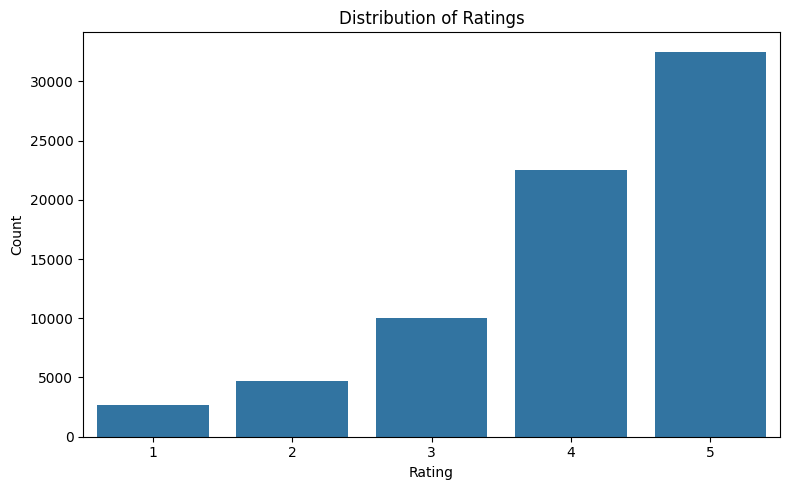

In [20]:
# Rating Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x="rating", data=df_clean)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

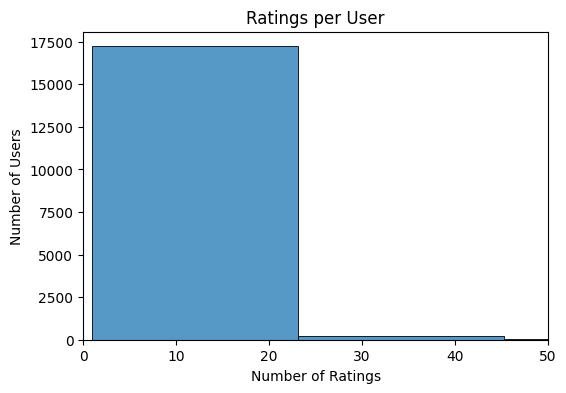

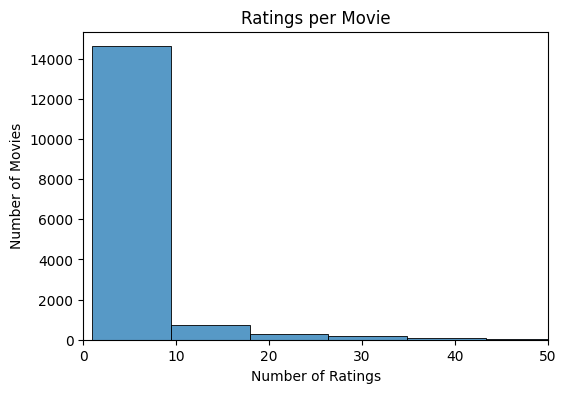

In [21]:
# Long-Trail Analysis
# Ratings per user
ratings_per_user = df_clean.groupby("userId").size()
ratings_per_movie = df_clean.groupby("movieId").size()

plt.figure(figsize=(6,4))
sns.histplot(ratings_per_user, bins=50)
plt.title("Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.xlim(0, 50)
plt.show()

# Ratings per movie
plt.figure(figsize=(6,4))
sns.histplot(ratings_per_movie, bins=50)
plt.title("Ratings per Movie")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Movies")
plt.xlim(0, 50)
plt.show()

In [22]:
# Data Filtering
# Keep only users with more than 5 ratings
df_filtered = df.groupby("userId").filter(lambda x: len(x) > 5)

# Keep only movies with more than 5 ratings
df_filtered = df_filtered.groupby("movieId").filter(lambda x: len(x) > 5)

print(f"Cleaned dataset shape: {df_clean.shape}")
print(f"Filtered dataset shape: {df_filtered.shape}")

Cleaned dataset shape: (72345, 6)
Filtered dataset shape: (27014, 6)


### Recommendation Models & Evaluation

In [23]:
# Train-test split
train_df, test_df = train_test_split(
    df_filtered,
    test_size=0.2,
    random_state=42
)

print("Training set:", train_df.shape)
print("Test set:", test_df.shape)


Training set: (21611, 6)
Test set: (5403, 6)


In [26]:
# Evaluation function
def evaluate_model(actual, predicted):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    return rmse, mae

#### Model 1: Global Average

In [27]:
# Global Average 
global_mean = train_df['rating'].mean()

test_df = test_df.copy()
test_df['global_pred'] = global_mean

global_rmse, global_mae = evaluate_model(
    test_df['rating'],
    test_df['global_pred']
)

print(f"Global Average RMSE: {global_rmse:.2f}")
print(f"Global Average MAE: {global_mae:.2f}")

Global Average RMSE: 1.07
Global Average MAE: 0.81


In [29]:
# User-movie matrix
user_movie_mx = train_df.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

user_movie_mx_filled = user_movie_mx.fillna(0)
print(f"Matrix shape: {user_movie_mx_filled.shape}")

# item similarity
item_similarity = cosine_similarity(user_movie_mx_filled.T)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=user_movie_mx.columns,
    columns=user_movie_mx.columns
)

print("Item similarity shape:", item_similarity_df.shape)

Matrix shape: (2008, 1825)
Item similarity shape: (1825, 1825)


#### Model 2: Item-Based CF (KNN)

In [30]:
# Item-based prediction function
def predict_item_based(user_id, movie_id, k=10):
    
    if user_id not in user_movie_mx.index:
        return global_mean
    
    if movie_id not in item_similarity_df.index:
        return global_mean
    
    user_ratings = user_movie_mx.loc[user_id].dropna()
    
    if len(user_ratings) == 0:
        return global_mean
    
    similarities = item_similarity_df[movie_id].loc[user_ratings.index]
    
    top_k = similarities.sort_values(ascending=False).head(k)
    top_ratings = user_ratings.loc[top_k.index]
    
    if top_k.sum() == 0:
        return global_mean
    
    pred = np.dot(top_k, top_ratings) / top_k.sum()
    
    return max(1, min(5, pred))

In [32]:
# Test item-based CF
test_df["item_cf_pred"] = test_df.apply(
    lambda row: predict_item_based(row["userId"], row["movieId"], k=10),
    axis=1
)

item_rmse, item_mae = evaluate_model(
    test_df["rating"],
    test_df["item_cf_pred"]
)

print("Item-Based CF RMSE:", item_rmse)
print("Item-Based CF MAE:", item_mae)

Item-Based CF RMSE: 1.0871065317247166
Item-Based CF MAE: 0.8222841068864251


In [35]:
# Hyperparameter tuning for k 
k_values = list(range(5, 31, 5)) 

rmse_scores = []
mae_scores = []

for k in k_values:
    
    preds = test_df.apply(
        lambda row: predict_item_based(row["userId"], row["movieId"], k=k),
        axis=1
    )
    
    rmse, mae = evaluate_model(test_df["rating"], preds)
    
    rmse_scores.append(rmse)
    mae_scores.append(mae)
    
    print(f"k={k}\n RMSE={rmse:.4f} \n MAE={mae:.4f}")


k=5
 RMSE=1.1068 
 MAE=0.8348
k=10
 RMSE=1.0871 
 MAE=0.8223
k=15
 RMSE=1.0835 
 MAE=0.8192
k=20
 RMSE=1.0817 
 MAE=0.8173
k=25
 RMSE=1.0807 
 MAE=0.8171
k=30
 RMSE=1.0803 
 MAE=0.8169


In [41]:
# Final model with best k
test_df["item_cf_pred"] = test_df.apply(
    lambda row: predict_item_based(row["userId"], row["movieId"], k=30),
    axis=1
)

item_rmse, item_mae = evaluate_model(
    test_df["rating"],
    test_df["item_cf_pred"]
)

#### Recommendation Quality (Precision@5 and Recall@5)

In [45]:
# Precision@K and Recall@K
relevant_threshold = 4
K = 5

# Top K predictions per user
top_k_preds = (
    test_df
    .sort_values(["userId", "item_cf_pred"], ascending=[True, False])
    .groupby("userId")
    .head(K)
)

# Mark relevant items
test_df["relevant"] = test_df["rating"] >= relevant_threshold
top_k_preds["relevant"] = top_k_preds["rating"] >= relevant_threshold

# precision@K
precision_at_k = (
    top_k_preds
    .groupby("userId")["relevant"]
    .mean()
    .mean()
)

print(f"Precision@{K}: {precision_at_k:.4f}")

# recall@K
relevant_total = test_df.groupby("userId")["relevant"].sum()
relevant_top_k = top_k_preds.groupby("userId")["relevant"].sum()

recall_at_k = (relevant_top_k / relevant_total).fillna(0).mean()

print(f"Recall@{K}: {recall_at_k:.4f}")

Precision@5: 0.7986
Recall@5: 0.8640


### Comparison Table

In [42]:
results = pd.DataFrame({
    "Model": ["Global Average", "Item-Based CF"],
    "RMSE": [global_rmse, item_rmse],
    "MAE": [global_mae, item_mae]
})

print(results)

            Model      RMSE       MAE
0  Global Average  1.074683  0.813989
1   Item-Based CF  1.080265  0.816886
